In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import matplotlib.pyplot as plt

import time, os, json, math
from tqdm.notebook import trange, tqdm

from shared import make_dataloaders, plot_line, visualize_umap_features, set_neurips_style

set_neurips_style()

In [ ]:
BASE = "vae-task"
BASE_PLOTS = os.path.join(BASE, "plots")
BASE_MODELS = os.path.join(BASE, "models")
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
BATCH_SIZE = 512
N_EPOCHS = 20
LEARNING_RATE = 1e-3
LATENT_DIMS = [2, 10, 128, 784]  # highest is 784 cuz 28x28 = 784, so model can potentially memorize at this point

os.makedirs(BASE_PLOTS, exist_ok=True)
os.makedirs(BASE_MODELS, exist_ok=True)
print(f"Using {DEVICE}")

Using cuda


# 1. Building a Basic VAE in PyTorch

In [ ]:
class Encoder(nn.Module):
    def __init__(self, img_shape, latent_dim):
        super(Encoder, self).__init__()
        
        self.latent_dim = latent_dim
        
        C, H, W = img_shape
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(H*W, out_features=512, bias=True, device=DEVICE),
            nn.ReLU(),
            nn.Linear(512, out_features=2*latent_dim, bias=True, device=DEVICE),
        )
        # mean is > 0 for pixels in [0, 1]
        # sigma is positive, but log-sigma can be negative, so no activation function for it
        # self.act_for_means = nn.ReLU()
    
    def forward(self, x):
        outs = self.layers(x)
        means, log_variances = outs[:, :self.latent_dim], outs[:, self.latent_dim:]
        return means, log_variances

In [ ]:
def sample_via_reparam_trick(means, log_variances):
    eps = torch.randn_like(means)
    
    variances = torch.exp(log_variances)
    stds = torch.sqrt(variances)
    
    return means + stds*eps

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Decoder, self).__init__()
        
        self.latent_dim = latent_dim
        
        C, H, W = img_shape
        self.layers = nn.Sequential(
            nn.Linear(latent_dim, out_features=2*latent_dim, bias=True, device=DEVICE),
            nn.ReLU(),
            nn.Linear(2*latent_dim, out_features=H*W, bias=True, device=DEVICE),
            # output image is in [0, 1]
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        return self.layers(x)

In [ ]:
class VAE(nn.Module):
    def __init__(self, img_shape, latent_dim):
        super(VAE, self).__init__()
        
        self.img_shape = img_shape
        self.encoder = Encoder(img_shape, latent_dim)
        self.decoder = Decoder(latent_dim, img_shape)
    
    def forward(self, x):
        means, log_variances = self.encoder(x)
        latent_z = sample_via_reparam_trick(means, log_variances)
        img = self.decoder(latent_z)
        
        B, N = img.shape
        
        return img.reshape(B, *self.img_shape), means, log_variances

In [ ]:
def elbo_loss(target_img, decoded_img, means, log_variances):
    B = target_img.shape[0]
    reconstruction_loss = nn.functional.binary_cross_entropy(input=decoded_img, target=target_img, reduction="mean")
    
    variances = torch.exp(log_variances)
    inner_term = means**2 + variances - log_variances - 1
    KL_div = 1/2 * torch.sum(inner_term, dim=-1)
    KL_div = KL_div.mean()
    
    return reconstruction_loss + 0.001*KL_div

In [ ]:
def load_mnist():
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    
    datasets = {
        phase: torchvision.datasets.MNIST(root='./mnist-data', train=(phase=="train"), download=True, transform=transform)
        for phase in ["train", "val"]
    }
    
    return make_dataloaders(datasets, batch_size=BATCH_SIZE, n_workers=12)

In [ ]:
print("Trainable parameters:", sum(p.numel() for p in VAE().parameters() if p.requires_grad))

In [28]:
dataloaders, dataset_sizes = load_mnist()

In [29]:
xb, yb = next(iter(dataloaders["train"]))

img_shape = xb.shape[1:]
img_mean = xb.mean(dim=[1,2,3]).mean()
img_std = xb.std(dim=[1,2,3]).mean()
img_min = xb.min()
img_max = xb.max()

print(f"Image stats:")
for stat, name in [
    (img_shape, "Shape"),
    (img_mean, "Mean"),
    (img_std, "Standard Dev"),
    (img_min, "Min"),
    (img_max, "Max"),
]:
    print(f"- {name}: {stat}")

Image stats:
- Shape: torch.Size([1, 28, 28])
- Mean: 0.12871257960796356
- Standard Dev: 0.2990923523902893
- Min: 0.0
- Max: 1.0


In [30]:
def train_vae(fpath, model, optimizer, dataloaders, dataset_sizes, num_epochs=25):
    since = time.time()
    metrics = {
        "train": {"loss": []},
        "val": {"loss": []},
    }

    base = os.path.dirname(fpath)
    fname = os.path.basename(fpath)
    best_model_params_path = os.path.join(base, f'best_{fname}.pt')

    torch.save(model.state_dict(), best_model_params_path)
    best_loss = float("inf")

    for epoch in (t := trange(num_epochs)):
        t.set_description_str(f'Epoch {epoch:3}/{num_epochs - 1:3}')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0

            for inputs, labels in tqdm(dataloaders[phase], total=len(dataloaders[phase]), leave=False):
                inputs = inputs.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                with torch.set_grad_enabled(phase == 'train'):
                    outputs, means, log_variances = model(inputs)
                    loss = elbo_loss(inputs, outputs, means, log_variances)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.detach() * inputs.size(0)
            
            epoch_loss = running_loss.item() / dataset_sizes[phase]

            t.set_description_str(f'[{epoch:3}] {phase} Loss: {epoch_loss:.4f}')
            metrics[phase]["loss"].append(epoch_loss)

            if phase == 'val' and epoch_loss < best_loss:
                best_loss = epoch_loss
                torch.save(model.state_dict(), best_model_params_path)

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val loss: {best_loss:4f}')

    model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    
    with open(os.path.join(base, f"{fname}.json"), "w") as f:
        f.write(json.dumps(metrics))


In [31]:
for latent_dim in LATENT_DIMS:
    print(f"Training with latent dim={latent_dim}")
    model = VAE(img_shape, latent_dim=latent_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_vae(os.path.join(BASE_MODELS, f"vae-task_latent-{latent_dim}"), model, optimizer, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

Training with latent dim=2


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/118 [00:00<?, ?it/s]

...

  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Training complete in 0m 20s
Best val loss: 0.131746


In [32]:
models = {}
for latent_dim in LATENT_DIMS:
    models[latent_dim] = VAE(img_shape, latent_dim=latent_dim)
    
    fname = f"vae-task_latent-{latent_dim}"
    best_model_params_path = os.path.join(BASE_MODELS, f'best_{fname}.pt')
    
    models[latent_dim].load_state_dict(torch.load(best_model_params_path, weights_only=True))

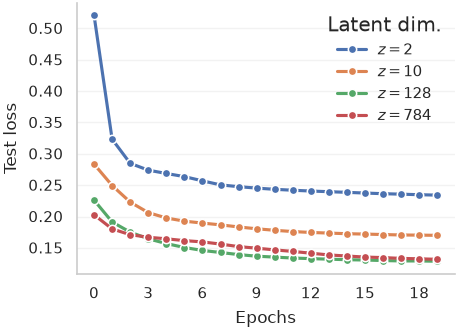

In [34]:
fig, ax1 = plt.subplots(1,1, figsize=(3.25,2.4))

for i, latent_dim in enumerate(LATENT_DIMS):
    fname = f"vae-task_latent-{latent_dim}"
    with open(os.path.join(BASE_MODELS, f"{fname}.json"), "r") as f:
        perf = json.loads(f.read())

    perf_df = pd.DataFrame(perf["val"])
    lineplot_kwargs = dict(label=f"$z={latent_dim}$", linewidth=1.5)
    
    configs = [
        {
            "column": "loss",
            "title": "",
            "xlabel": "Epochs",
            "ylabel": "Test loss",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax1},
        },
    ]
    
    plot_line(perf_df, configs)

ax1.grid(axis="y", alpha=0.25, linewidth=0.7)
ax1.grid(axis="x", visible=False)
ax1.legend(title="Latent dim.", frameon=False, loc="best")

fig.tight_layout()
plt.savefig(os.path.join(BASE_PLOTS, "losses.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# 2. Analyzing VAE Performance

In [35]:
n_batches = 3
test_imgs, test_labels = [], []
for _ in range(n_batches):
    batch_imgs, batch_labels = next(iter(dataloaders["val"]))
    
    test_imgs.append(batch_imgs)
    test_labels.append(batch_labels)

test_imgs = torch.concat(test_imgs)
test_labels = torch.concat(test_labels)
print(test_imgs.shape, test_labels.shape)

torch.Size([1536, 1, 28, 28]) torch.Size([1536])


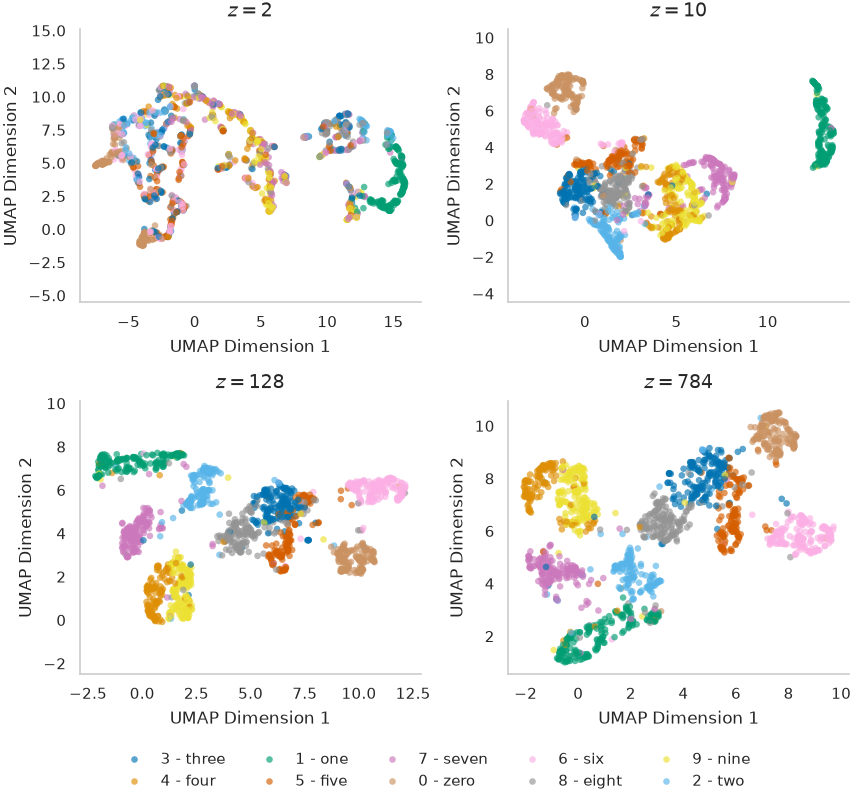

In [36]:
ncols = 2
nrows = math.ceil(len(LATENT_DIMS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.8, 2.7*nrows), squeeze=False)
axes = axes.flatten()

for i, latent_dim in enumerate(LATENT_DIMS):
    model_vis = models[latent_dim]
    with torch.no_grad():
        means, log_variances = model_vis.encoder(test_imgs.to(DEVICE, non_blocking=True))

    visualize_umap_features(
        means.cpu(),
        test_labels,
        dataloaders["val"].dataset.classes,
        ax=axes[i],
        legend=(i==0),
        title=f"$z={latent_dim}$",
    )

for ax in axes[len(LATENT_DIMS):]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=7,
    bbox_to_anchor=(0.5, -0.01),
)
fig.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(os.path.join(BASE_PLOTS, f"umap_latents.pdf"), bbox_inches="tight", dpi=300)
plt.show()

In [37]:
def plot_reconstruction_pair(
    reconstructed,
    image,
    axes,
):
    original_ax, reconstruction_ax = axes

    reconstructed = reconstructed.squeeze().numpy()
    image = image.squeeze().numpy()

    original_ax.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    reconstruction_ax.imshow(
        reconstructed,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    original_ax.axis("off")
    reconstruction_ax.axis("off")


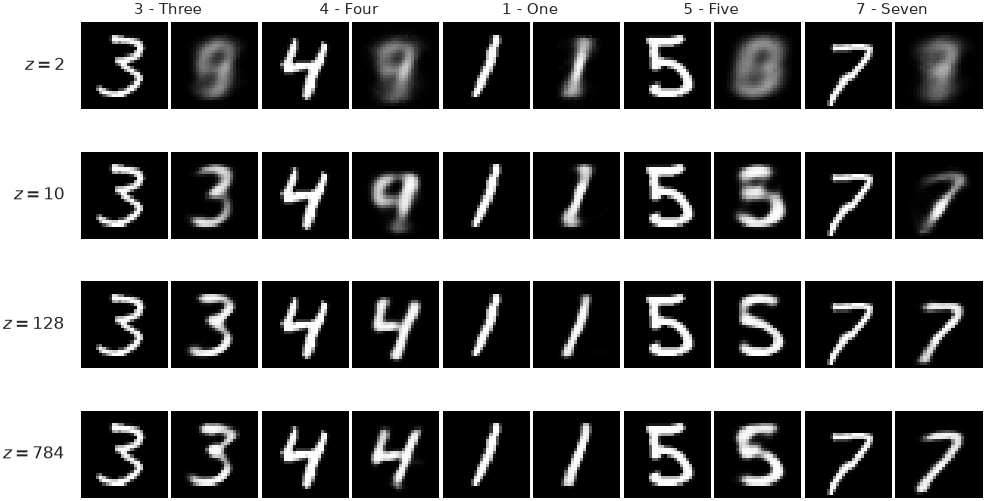

In [38]:
num_samples = 5
num_latents = len(LATENT_DIMS)

class_names = dataloaders["val"].dataset.classes

fig, axes = plt.subplots(
    num_latents,
    num_samples * 2,
    figsize=(6.5, 0.95 * num_latents),
    squeeze=False,
)

for row, latent_dim in enumerate(LATENT_DIMS):

    model_vis = models[latent_dim]

    with torch.inference_mode():
        reconstructed, means, log_variances = model_vis(
            test_imgs.to(DEVICE, non_blocking=True)
        )

    for col in range(num_samples):

        plot_reconstruction_pair(
            reconstructed[col].cpu(),
            test_imgs[col].cpu(),
            axes[row, 2 * col : 2 * col + 2],
        )

    # Latent dimensionality
    axes[row, 0].text(
        -0.18,
        0.5,
        fr"$z={latent_dim}$",
        transform=axes[row, 0].transAxes,
        ha="right",
        va="center",
        fontsize=8,
    )


# Class labels: only once, at the top
for col in range(num_samples):

    # Put class name between the two images in the pair
    axes[0, 2 * col].set_title(
        class_names[test_labels[col]].title(),
        fontsize=7,
        fontweight="normal",
        pad=4,
        x=1.0,
    )


fig.subplots_adjust(
    left=0.07,
    right=0.995,
    top=0.88,
    bottom=0.03,
    wspace=0.04,
    hspace=0.35,
)

fig.savefig(
    os.path.join(
        BASE_PLOTS,
        "reconstructions_latents.pdf",
    ),
    bbox_inches="tight",
)

plt.show()


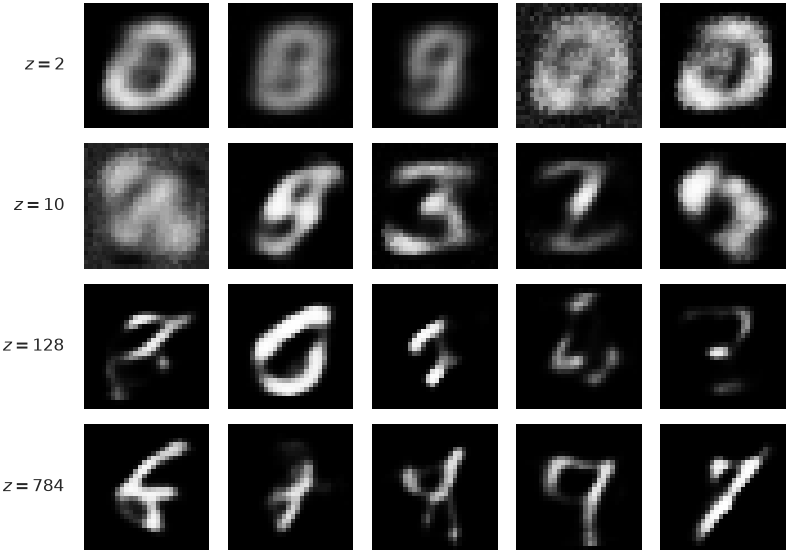

In [39]:
def plot_generated_sample(sample, ax):
    sample = sample.squeeze().numpy()

    ax.imshow(
        sample,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    ax.axis("off")

num_samples = 5
num_latents = len(LATENT_DIMS)
generator = torch.Generator(device=DEVICE)

fig, axes = plt.subplots(
    num_latents,
    num_samples,
    figsize=(5.2, 0.95 * num_latents),
    squeeze=False,
)

for row, latent_dim in enumerate(LATENT_DIMS):
    model_vis = models[latent_dim]
    random_latents = torch.randn(
        size=(num_samples, latent_dim),
        device=DEVICE,
        generator=generator,
    )

    with torch.inference_mode():
        samples = model_vis.decoder(random_latents)
        samples = samples.reshape(
            samples.shape[0],
            *img_shape,
        )

    for col in range(num_samples):
        plot_generated_sample(
            samples[col].cpu(),
            axes[row, col],
        )

    # Latent dimension label
    axes[row, 0].text(
        -0.15,
        0.5,
        fr"$z={latent_dim}$",
        transform=axes[row, 0].transAxes,
        ha="right",
        va="center",
        fontsize=8,
    )


fig.subplots_adjust(
    left=0.08,
    right=0.995,
    top=0.98,
    bottom=0.02,
    wspace=0.05,
    hspace=0.12,
)

fig.savefig(
    os.path.join(
        BASE_PLOTS,
        "generated_samples_latents.pdf",
    ),
    bbox_inches="tight",
)

plt.show()
